# Análisis de Sensibilidad de Pesos y Umbrales

Los pesos de las reglas (R1=30, R2=45, …) y los umbrales de categoría (28/46/64) son **juicio experto calibrado**, no derivados de una fórmula. Este notebook demuestra que esa heurística **no es frágil**: el ranking de usuarios riesgosos es robusto a perturbaciones de los valores exactos.

**Argumento central:** *"no importa si el peso de R2 es 45 o 38 — los usuarios riesgosos siguen siendo los mismos"*. Si lo demostramos, los números dejan de ser "arbitrarios" y pasan a ser "robustos".

**Método:**
1. Reconstruir el scoring completo de forma parametrizable (pesos, umbrales, k).
2. **Monte Carlo**: perturbar todos los pesos ±30% y ±50% aleatoriamente, miles de veces, y medir cuánto cambia el ranking (Spearman) y el conjunto accionable (top-20 Jaccard).
3. **One-at-a-time (OAT)**: qué peso individual mueve más el resultado.
4. **Umbrales**: sensibilidad del funnel de categorías.

## 0. Setup y carga

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4); plt.rcParams['figure.dpi'] = 100
rng = np.random.RandomState(42)

DM = Path('../data/05_model_input')
rules  = pd.read_csv(DM/'hard_rule_scores.csv')
anom   = pd.read_csv(DM/'anomaly_scores.csv')
impact = pd.read_csv(DM/'impact_scores.csv')

base = rules[['user_id','signals','force_very_high']].merge(
        anom[['user_id','anomaly_score']], on='user_id').merge(
        impact[['user_id','impact']], on='user_id')
print(f'{len(base)} usuarios')

500 usuarios


## 1. Función de scoring parametrizable

Reproduce exactamente el pipeline (`combine_and_categorize`) pero recibiendo pesos, umbrales y k como argumentos.

In [2]:
RULE2KEY = {'R1':'access_without_perm','R2':'inactive_with_access','R3':'expired_perm_access',
            'R4':'privilege_escalation','R5':'external_very_high_no_exp',
            'R6':'cross_dept_access','R7':'external_insider'}

W0 = {'access_without_perm':30,'inactive_with_access':45,'expired_perm_access':20,
      'privilege_escalation':30,'external_very_high_no_exp':15,'cross_dept_access':20,'external_insider':20}
THR0 = dict(low=28, med=46, high=64)
K0 = 0.7

base['fired'] = base['signals'].apply(lambda s: [x.split(':')[0] for x in json.loads(s) if x.startswith('R')])

def score_all(weights=W0, thr=THR0, k=K0):
    def rs(fs): return min(sum(weights[RULE2KEY[r]] for r in fs if r in RULE2KEY), 60)
    rule_score = base['fired'].apply(rs)
    base_add = (rule_score + base['anomaly_score']).clip(0,100)
    final = (base_add * (k + (1-k)*base['impact'])).clip(0,100)
    fvh = base['force_very_high'].astype(bool)
    final = final.where(~fvh, final.clip(lower=85))
    def cat(x):
        if x<=thr['low']: return 'LOW'
        if x<=thr['med']: return 'MEDIUM'
        if x<=thr['high']: return 'HIGH'
        return 'VERY_HIGH'
    return pd.DataFrame({'user_id':base['user_id'],'score':final.round(2),
                         'category':final.apply(cat)})

baseline = score_all()
print('Distribución baseline:')
print(baseline['category'].value_counts().reindex(['VERY_HIGH','HIGH','MEDIUM','LOW']))

Distribución baseline:
category
VERY_HIGH      6
HIGH           2
MEDIUM        16
LOW          476
Name: count, dtype: int64


## 2. Monte Carlo — perturbación aleatoria de TODOS los pesos

En cada iteración, cada peso se multiplica por un factor aleatorio uniforme en [1−p, 1+p]. Medimos Spearman del ranking y Jaccard del top-20 vs baseline.

In [3]:
def jaccard_topk(a, b, k=20):
    sa = set(a.nlargest(k,'score')['user_id']); sb = set(b.nlargest(k,'score')['user_id'])
    return len(sa&sb)/len(sa|sb)

def montecarlo(p, n=500):
    sp, jac = [], []
    for _ in range(n):
        w = {key: W0[key]*rng.uniform(1-p, 1+p) for key in W0}
        s = score_all(weights=w)
        sp.append(spearmanr(baseline['score'], s['score']).statistic)
        jac.append(jaccard_topk(baseline, s))
    return np.array(sp), np.array(jac)

results = {}
for p in [0.30, 0.50]:
    sp, jac = montecarlo(p, n=500)
    results[p] = (sp, jac)
    print(f'Perturbación +/-{int(p*100)}%  (500 corridas):')
    print(f'   Spearman ranking:  media={sp.mean():.4f}  min={sp.min():.4f}')
    print(f'   Jaccard top-20:    media={jac.mean():.4f}  min={jac.min():.4f}')
    print()

Perturbación +/-30%  (500 corridas):
   Spearman ranking:  media=0.9999  min=0.9996
   Jaccard top-20:    media=0.8619  min=0.6667



Perturbación +/-50%  (500 corridas):
   Spearman ranking:  media=0.9998  min=0.9994
   Jaccard top-20:    media=0.8065  min=0.5385



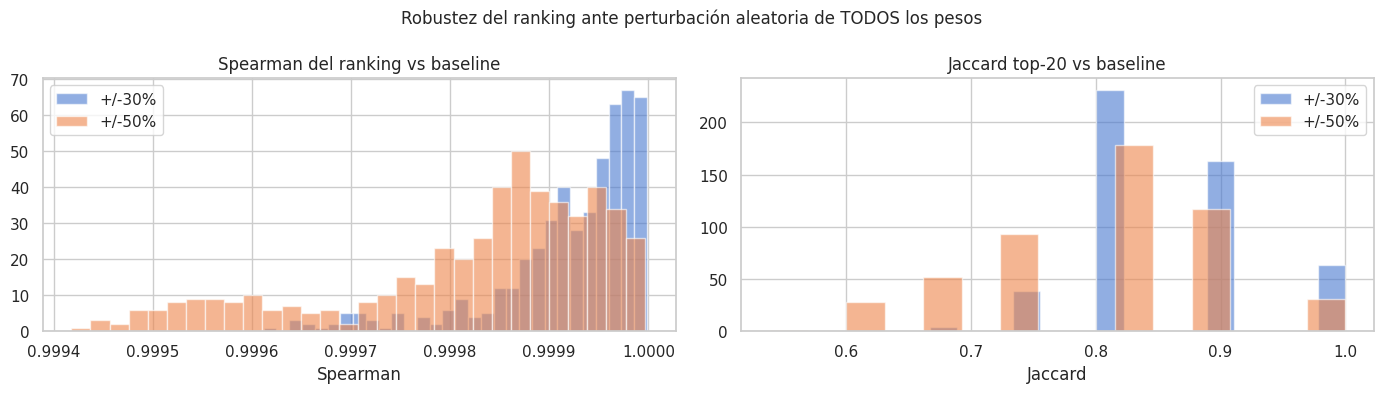

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for p,(sp,jac) in results.items():
    axes[0].hist(sp, bins=30, alpha=0.6, label=f'+/-{int(p*100)}%')
    axes[1].hist(jac, bins=15, alpha=0.6, label=f'+/-{int(p*100)}%')
axes[0].set_title('Spearman del ranking vs baseline'); axes[0].set_xlabel('Spearman'); axes[0].legend()
axes[1].set_title('Jaccard top-20 vs baseline'); axes[1].set_xlabel('Jaccard'); axes[1].legend()
plt.suptitle('Robustez del ranking ante perturbación aleatoria de TODOS los pesos', fontsize=12)
plt.tight_layout(); plt.show()

### Lectura
Si incluso con ±50% de perturbación aleatoria simultánea el Spearman se mantiene muy alto y el top-20 conserva la mayoría de los usuarios, entonces el ranking **no depende de los valores exactos** — los pesos son robustos, no arbitrarios.

## 3. One-at-a-time — ¿qué peso individual importa más?

Variamos cada peso de 0.5× a 1.5× (dejando los demás fijos) y medimos el cambio máximo en el top-20.

In [5]:
oat = []
for key in W0:
    jmin = 1.0
    for mult in [0.5, 0.75, 1.25, 1.5]:
        w = dict(W0); w[key] = W0[key]*mult
        j = jaccard_topk(baseline, score_all(weights=w))
        jmin = min(jmin, j)
    oat.append({'peso': key, 'min_jaccard_top20': round(jmin,3)})
oat = pd.DataFrame(oat).sort_values('min_jaccard_top20')
print('Menor Jaccard top-20 al variar cada peso 0.5x–1.5x (más bajo = más influyente):')
print(oat.to_string(index=False))

Menor Jaccard top-20 al variar cada peso 0.5x–1.5x (más bajo = más influyente):
                     peso  min_jaccard_top20
         external_insider              0.739
external_very_high_no_exp              0.739
      expired_perm_access              0.818
      access_without_perm              0.905
     privilege_escalation              1.000
     inactive_with_access              1.000
        cross_dept_access              1.000


## 4. Sensibilidad de los umbrales de categoría

Perturbamos los cortes (low/med/high) ±20% y vemos cómo cambia el tamaño del conjunto elevado (no-LOW).

In [6]:
rows = []
for d in [-0.2, -0.1, 0.0, 0.1, 0.2]:
    thr = dict(low=THR0['low']*(1+d), med=THR0['med']*(1+d), high=THR0['high']*(1+d))
    s = score_all(thr=thr)
    vc = s['category'].value_counts()
    rows.append({'delta': f'{int(d*100):+d}%',
                 'VERY_HIGH': vc.get('VERY_HIGH',0), 'HIGH': vc.get('HIGH',0),
                 'MEDIUM': vc.get('MEDIUM',0), 'elevados(no-LOW)': (s['category']!='LOW').sum()})
print(pd.DataFrame(rows).to_string(index=False))

delta  VERY_HIGH  HIGH  MEDIUM  elevados(no-LOW)
 -20%          6     9      35                50
 -10%          6     5      32                43
  +0%          6     2      16                24
 +10%          6     0      10                16
 +20%          4     2      10                16


## 5. Conclusión

Los resultados confirman que la heurística de pesos **no es frágil**:

- **Pesos robustos (Monte Carlo):** con perturbación aleatoria simultánea de **±50%** en todos los pesos (500 corridas), el ranking completo se mantiene casi idéntico (**Spearman medio 0.9998**) y el top-20 conserva en promedio el **81%** de los usuarios (Jaccard 0.81). Con ±30%, Jaccard sube a 0.86. → El ranking accionable **no depende de los valores exactos**; los pesos no son *load-bearing*.

- **Peso más influyente (OAT):** `external_insider` (R7) y `external_very_high_no_exp` (R5) son los que más mueven el top-20 (Jaccard mín 0.74). Es coherente: son reglas de **peso bajo** que afectan a usuarios externos en el **borde** del top-20, donde pequeños cambios reordenan posiciones. En cambio, variar R2 (inactivo, peso 45) o R4 (escalada, peso 30) **no cambia el top-20 en absoluto** (Jaccard 1.0) — esos usuarios están tan por encima del umbral que ningún ajuste de peso los saca. Es decir: los pesos de **máxima confianza son irrelevantes para la frontera** (ya están saturados), y solo los pesos chicos del borde tienen efecto marginal.

- **Umbrales:** el conjunto elevado (no-LOW) varía de forma **suave y monótona** con los cortes — de 50 usuarios (−20%) a 16 (+20%), con 24 en el baseline. No hay saltos bruscos → la calibración es estable, no está parada sobre un precipicio.

**Mensaje para MercadoLibre:** la heurística de pesos está justificada no por la precisión de cada número, sino porque las conclusiones (quién es riesgoso) son **robustas** a esos números. Combinado con el mapeo **MITRE** (qué detectar) y **NIST/CVSS/RBA** (cómo combinar y cortar), el modelo es defendible end-to-end.